In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

google_sheet_csv_url = "https://docs.google.com/spreadsheets/d/1XEFg047aSbg3OsEVx9PzmgSxGbCvCidfLiHfsgRS3R0/gviz/tq?tqx=out:csv&gid=0"

covid_data = pd.read_csv(google_sheet_csv_url, on_bad_lines='skip')

In [34]:
covid_data['Date Announced'] = pd.to_datetime(covid_data['Date Announced'])

In [35]:
covid_data

,Prefecture Patient Number,City Patient Number,Date Announced,Date Added,Age Bracket,Gender,"Residence City, Prefecture",Detected City,Detected Prefecture,Status,Notes,Source(s),Related Patients,Known Cluster,Deceased,MHLW (Orig) Patient Number,Charter Flight Passenger,Cruise Passenger (Disembarked),Has ID,Prefecture URL (Auto)
0,1.0,NaN,2020-01-30,2020-01-30,50.0,M,"Wuhan, China",NaN,Unspecified,Discharged,Japanese lives in China,https://www.mhlw.go.jp/stf/newpage_09531.html,NaN,Charter Flight,NaN,9.0,1.0,NaN,0.0,NaN
1,2.0,NaN,2020-02-01,2020-02-01,40.0,M,Unspecified,NaN,Unspecified,Discharged,NaN,https://www.mhlw.go.jp/stf/newpage_09531.html,3,Charter Flight,NaN,14.0,1.0,NaN,0.0,NaN
2,3.0,NaN,2020-02-01,2020-02-01,40.0,M,China,NaN,Unspecified,Discharged,Japanese lives in China,https://www.mhlw.go.jp/stf/newpage_09531.html,2,Charter Flight,NaN,15.0,1.0,NaN,0.0,NaN
3,4.0,Chiba#2,2020-02-01,2020-02-01,40.0,M,"Wuhan, China",NaN,Chiba,Discharged,Japanese lives in China,https://www.mhlw.go.jp/stf/newpage_09531.html,NaN,Charter Flight,NaN,16.0,1.0,NaN,2.0,NaN
4,5.0,ChibaAsymp#1,2020-01-30,2020-02-04,50.0,F,Chiba,NaN,Chiba,Discharged,NaN,https://www.mhlw.go.jp/stf/newpage_09531.html,NaN,Charter Flight,NaN,18.0,1.0,NaN,1.0,https://www.mhlw.go.jp/stf/newpage_09531.html
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7001,9101.0,Hyogo#646,2020-04-30,2020-04-30,50.0,F,Amagasaki,NaN,Hyogo,NaN,NaN,http://web.pref.hyogo.lg.jp/kk03/corona_hassei...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7002,9102.0,NaN,2020-04-30,2020-04-30,NaN,NaN,Funabashi,NaN,Chiba,NaN,NaN,https://www3.nhk.or.jp/news/html/20200430/k100...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7003,9103.0,NaN,2020-04-30,2020-04-30,NaN,NaN,Funabashi,NaN,Chiba,NaN,NaN,https://www3.nhk.or.jp/news/html/20200430/k100...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
7004,9104.0,NaN,2020-04-30,2020-04-30,NaN,NaN,Funabashi,NaN,Chiba,NaN,NaN,https://www3.nhk.or.jp/news/html/20200430/k100...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [41]:
covid_data['Detected City'].unique()

array([nan, 'Kyoto', 'Chiba', 'Yuasa', 'Ichikawa', 'Sapporo', 'Kanagawa',
       'Wakayama', 'Nanae, Oshima', 'Kashiwa', 'Nakafurano',
       'Chitose, Ishikari', 'Kumamoto', 'Iburi', 'Nemuro', 'Asahikawa',
       'Ebetsu', 'Hakodate', 'Shiriuchi, Oshima', 'Kitami, Okhotsk',
       'Kamikawa', 'Biei, Kamikawa', 'Kushiro', 'Ishikari', 'Matsudo',
       'Okhotsk', 'Kanazawa', 'Nagano', 'Aizumi', 'Hidaka', 'Isumishi',
       'Yotsukaido', 'Matsumoto', 'Ogaki', 'Akkeshi, Kushiro',
       'Takikawa, Sorachi', 'Tokachi', 'Setana, Hiyama', 'Yakumo, Oshima',
       'Kikonai, Oshima', 'Yokohama', 'Fukagawa, Sorachiso',
       'Nakafurano, Kamikawa', 'Shizuoka', 'Ishikawa', 'Kochi', 'Niigata',
       'Sendai', 'Tomakomai', 'Funabashi', 'Kita-Kyushu', 'Nishinomiya',
       'Ainan', 'Kamo', 'Higashi Ward, Niigata', 'Chuo Ward, Niigata',
       'Oita', 'Kobe', 'Kyoto city', 'Shimonoseki', 'Matsuyama', 'Aki',
       'Chubu International', 'Miyazaki', 'Otsu', 'Fukusaki', 'Gyoda',
       'Ageo', 'Nanm

a) Liệt kê số ca nhiễm theo từng thành phố (Detected City).

In [ ]:
print("\n--- a) Số ca nhiễm theo từng thành phố ---")

# Đảm bảo cột Detected City không có giá trị NaN trước khi nhóm
covid_data_cleaned_for_city = covid_data.dropna(subset=['Detected City'])

# Sử dụng .size() để đếm số lượng ca nhiễm (số hàng) trong mỗi thành phố
cases_by_city = covid_data_cleaned_for_city.groupby('Detected City').size().sort_values(ascending=False)

cases_by_city


--- a) Số ca nhiễm theo từng thành phố ---


Detected City
Sapporo         188
Fukuoka City    101
Tonosho         100
Fukuoka city     96
Kyoto City       86
               ... 
Kaga              1
Sakahogi          1
Iwakuni           1
Iwade             1
Shinjō            1
Length: 474, dtype: int64

b) Liệt kê số ca nhiễm theo độ tuổi, vẽ biểu đồ.

In [39]:
print("--- b) Số ca nhiễm theo độ tuổi ---")

# Đảm bảo cột 'Age Bracket' không có giá trị NaN trước khi nhóm
# Chuyển đổi 'Age Bracket' sang dạng số (nếu nó ở dạng '20s', '30s' thì sẽ giữ nguyên dạng string)
# Nếu muốn xử lý số, có thể cần thêm bước trích xuất số từ chuỗi '20s'
cases_by_age = covid_data.dropna(subset=['Age Bracket']).groupby('Age Bracket').size().sort_index()

print(cases_by_age)
print("\n")

--- b) Số ca nhiễm theo độ tuổi ---
Age Bracket
0.0       116
10.0      196
20.0      991
30.0      852
40.0     1045
50.0     1232
60.0      843
70.0      667
80.0      530
90.0      193
100.0       3
dtype: int64




C:\Users\Thy\AppData\Local\Temp\ipykernel_3964\1253487598.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=cases_by_age.index, y=cases_by_age.values, palette='viridis')


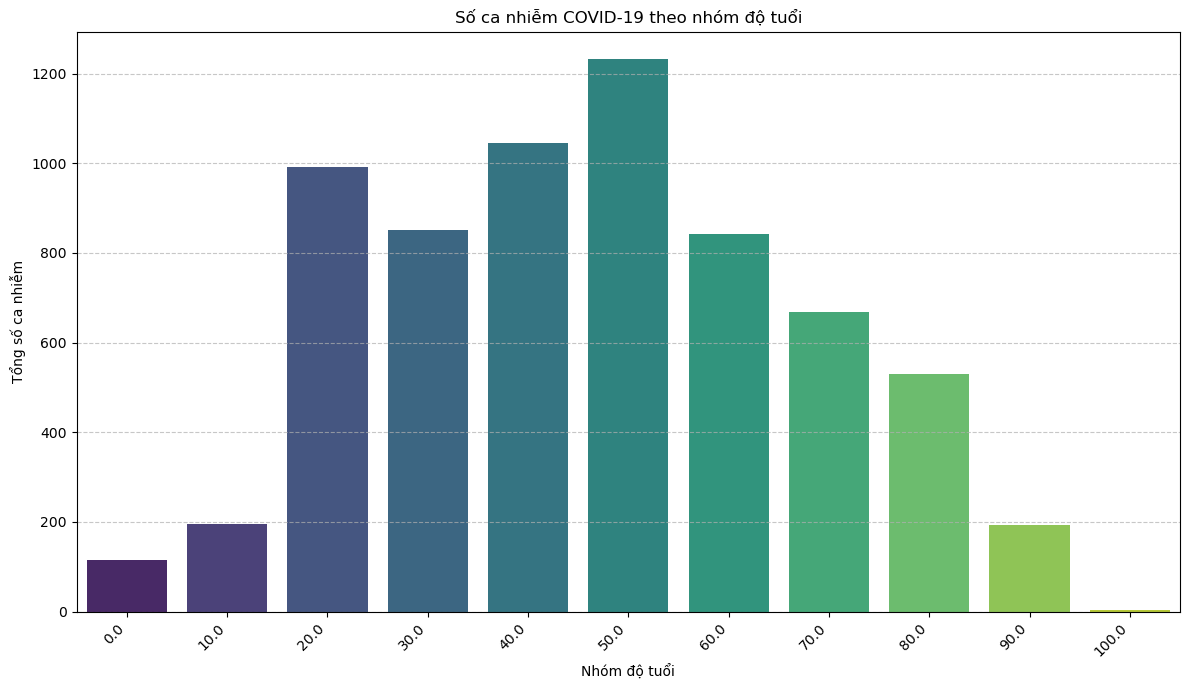

In [40]:
# Vẽ biểu đồ cột cho số ca nhiễm theo độ tuổi
plt.figure(figsize=(12, 7))
sns.barplot(x=cases_by_age.index, y=cases_by_age.values, palette='viridis')
plt.title('Số ca nhiễm COVID-19 theo nhóm độ tuổi')
plt.xlabel('Nhóm độ tuổi')
plt.ylabel('Tổng số ca nhiễm')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

 c) Liệt kê số ca nhiễm tại Hokkaido theo từng ngày. Vẽ biểu đồ.

--- c) Số ca nhiễm tại Hokkaido theo từng ngày ---
Date Announced
2020-01-28     1
2020-02-14     1
2020-02-18     1
2020-02-19     1
2020-02-20     1
              ..
2020-04-26    14
2020-04-27    36
2020-04-28    39
2020-04-29    38
2020-04-30    41
Length: 71, dtype: int64




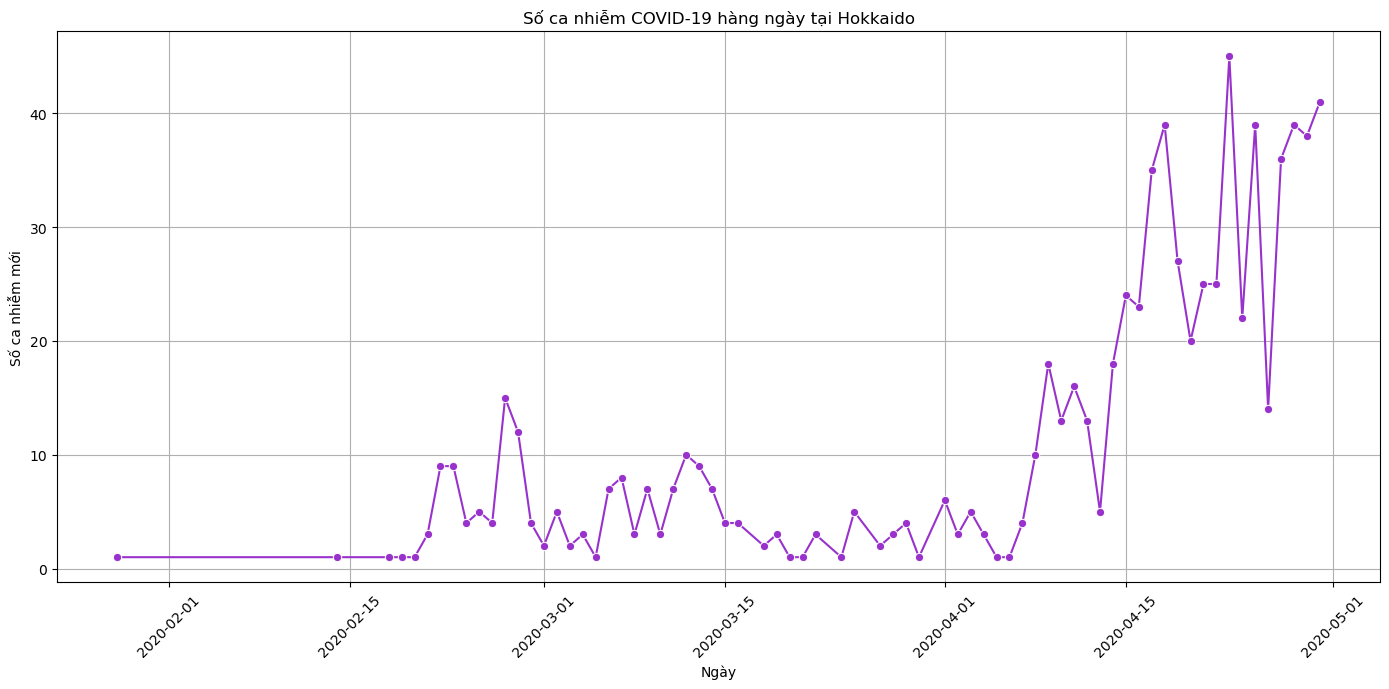

In [47]:
print("--- c) Số ca nhiễm tại Hokkaido theo từng ngày ---")

# Lọc dữ liệu cho thành phố Hokkaido và đảm bảo cột 'date' không NaN
hokkaido_data = covid_data[covid_data['Detected Prefecture'] == 'Hokkaido']

# Sử dụng .size() để đếm số lượng ca nhiễm (số hàng) mỗi ngày tại Hokkaido
hokkaido_cases_daily = hokkaido_data.groupby('Date Announced').size().sort_index()

if not hokkaido_cases_daily.empty:
    print(hokkaido_cases_daily)
    print("\n")

    # Vẽ biểu đồ đường cho số ca nhiễm hàng ngày tại Hokkaido
    plt.figure(figsize=(14, 7))
    sns.lineplot(x=hokkaido_cases_daily.index, y=hokkaido_cases_daily.values, marker='o', color='darkorchid')
    plt.title('Số ca nhiễm COVID-19 hàng ngày tại Hokkaido')
    plt.xlabel('Ngày')
    plt.ylabel('Số ca nhiễm mới')
    plt.grid(True)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
else:
    print("Không tìm thấy dữ liệu ca nhiễm cho Hokkaido hoặc dữ liệu không hợp lệ.")

In [48]:
hokkaido_data

,Prefecture Patient Number,City Patient Number,Date Announced,Date Added,Age Bracket,Gender,"Residence City, Prefecture",Detected City,Detected Prefecture,Status,Notes,Source(s),Related Patients,Known Cluster,Deceased,MHLW (Orig) Patient Number,Charter Flight Passenger,Cruise Passenger (Disembarked),Has ID,Prefecture URL (Auto)
15,21.0,Hokkaido#1,2020-01-28,2020-01-28,40.0,F,"Wuhan, China",NaN,Hokkaido,Discharged,Chinese traveler,https://www.mhlw.go.jp/stf/newpage_09531.html,NaN,NaN,NaN,7.0,NaN,NaN,1.0,http://www.pref.hokkaido.lg.jp/hf/kth/kak/hass...
28,41.0,Hokkaido#2,2020-02-14,2020-02-14,50.0,M,Sapporo,Sapporo,Hokkaido,NaN,NaN,https://www.mhlw.go.jp/stf/newpage_09539.html,NaN,NaN,NaN,36.0,NaN,NaN,2.0,http://www.pref.hokkaido.lg.jp/hf/kth/kak/hass...
39,66.0,Hokkaido#4,2020-02-19,2020-02-19,60.0,M,Hokkaido,"Nanae, Oshima",Hokkaido,Discharged,NaN,https://www3.nhk.or.jp/news/html/20200219/k100...,Contact with Hokkaido#5,NaN,NaN,64.0,NaN,NaN,4.0,http://www.pref.hokkaido.lg.jp/hf/kth/kak/hass...
40,69.0,Hokkaido#3,2020-02-18,2020-02-19,40.0,M,Sapporo,Sapporo,Hokkaido,Hospitalized,NaN,https://www3.nhk.or.jp/news/html/20200219/k100...,Source of Hokkaido#12,NaN,NaN,63.0,NaN,NaN,3.0,http://www.pref.hokkaido.lg.jp/hf/kth/kak/hass...
44,77.0,Hokkaido#5,2020-02-20,2020-02-20,40.0,M,Sapporo,Sapporo,Hokkaido,NaN,NaN,https://www3.nhk.or.jp/news/html/20200220/k100...,Contact with Hokkaido#3,NaN,NaN,72.0,NaN,NaN,5.0,http://www.pref.hokkaido.lg.jp/hf/kth/kak/hass...
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6993,9094.0,NaN,2020-04-30,2020-04-30,NaN,NaN,Otaru,NaN,Hokkaido,NaN,NaN,https://www3.nhk.or.jp/news/html/20200430/k100...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6994,9095.0,NaN,2020-04-30,2020-04-30,NaN,NaN,Otaru,NaN,Hokkaido,NaN,NaN,https://www3.nhk.or.jp/news/html/20200430/k100...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6995,9096.0,NaN,2020-04-30,2020-04-30,NaN,NaN,Otaru,NaN,Hokkaido,NaN,NaN,https://www3.nhk.or.jp/news/html/20200430/k100...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
6996,9097.0,NaN,2020-04-30,2020-04-30,NaN,NaN,Otaru,NaN,Hokkaido,NaN,NaN,https://www3.nhk.or.jp/news/html/20200430/k100...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [49]:
hokkaido_cases_daily

Date Announced
2020-01-28     1
2020-02-14     1
2020-02-18     1
2020-02-19     1
2020-02-20     1
              ..
2020-04-26    14
2020-04-27    36
2020-04-28    39
2020-04-29    38
2020-04-30    41
Length: 71, dtype: int64